***# Setup:***


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load all 4 datasets
crop_df = pd.read_csv('crop_clean.csv')
rain_df = pd.read_csv('rain_clean.csv')
temp_df = pd.read_csv('temp_clean.csv')
water_df = pd.read_csv('water_clean.csv')

print("✓ All datasets loaded")
print(f" Crop: {crop_df.shape}")
print(f" Rain: {rain_df.shape}")
print(f" Temp: {temp_df.shape}")
print(f" Water: {water_df.shape}")

✓ All datasets loaded
 Crop: (288991, 8)
 Rain: (4188, 19)
 Temp: (33, 18)
 Water: (194, 21)


***# Understanding the merge challenge:***

In [ ]:
# What columnd csn we merge on?
print("=== MERGE KEY ANALYSISI ===")
print("\nCrop columns:", crop_df.columns.tolist())
print("\nRain columns:", rain_df.columns.tolist())
print("\nTemp columns:", temp_df.columns.tolist())
print("\nWater columns:", water_df.columns.tolist())

print("\n=== COMMON POTENTIAL KEYS ===")
print("Crop has: State + Crop_Year")
print("Rain has: SUBDIVISION + YEAR")
print("Temp has: State (no year - long-term average)")
print("Water has: State Name + Year")

print("\n=== YEAR OVERLAPS ===")
print(f"Crop years: {crop_df['Crop_Year'].min()} - {crop_df['Crop_Year'].max()}")
print(f"Rain years: {rain_df['YEAR'].min()} - {rain_df['YEAR'].max()}")
print(f"Water years: {water_df['Year'].min()} - {water_df['Year'].max()}")
print(f"Temp:         Long-term average (no year)")
print(f"\nUsable overlap: 1997–2017 (crop + rain overlap)")

=== MERGE KEY ANALYSISI ===

Crop columns: ['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area', 'Production', 'Yield']

Rain columns: ['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS', 'OND']

Temp columns: ['State', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'annual_mean_temp', 'summer_temp', 'monsoon_temp', 'winter_temp', 'temp_range']

Water columns: ['STN code', 'Monitoring Location', 'Year', 'Type Water Body', 'State Name', 'Temperature (C) - Min', 'Temperature (C) - Max', 'Dissolved - Min', 'Dissolved - Max', 'pH - Min', 'pH - Max', 'Conductivity (¬µmho/cm) - Min', 'Conductivity (¬µmho/cm) - Max', 'BOD (mg/L) - Min', 'BOD (mg/L) - Max', 'NitrateN (mg/L) - Min', 'NitrateN (mg/L) - Max', 'Fecal Coliform (MPN/100ml) - Min', 'Fecal Coliform (MPN/100ml) - Max', 'Total Coliform (MPN/100ml) - Min', 'Total Coliform (MPN/100ml) - Max']

=== COMMON POTE

***# Prepare rainfall Dataset:***


In [32]:
# Print all unique subdivisions to understand what we're working with
print("Rainfall subdivisions:")
for s in sorted(rain_df['SUBDIVISION'].unique()):
    print(f"  '{s}'")

Rainfall subdivisions:
  'Andaman & Nicobar Islands'
  'Arunachal Pradesh'
  'Assam & Meghalaya'
  'Bihar'
  'Chhattisgarh'
  'Coastal Andhra Pradesh'
  'Coastal Karnataka'
  'East Madhya Pradesh'
  'East Rajasthan'
  'East Uttar Pradesh'
  'Gangetic West Bengal'
  'Gujarat Region'
  'Haryana Delhi & Chandigarh'
  'Himachal Pradesh'
  'Jammu & Kashmir'
  'Jharkhand'
  'Kerala'
  'Konkan & Goa'
  'Lakshadweep'
  'Madhya Maharashtra'
  'Matathwada'
  'Naga Mani Mizo Tripura'
  'North Interior Karnataka'
  'Orissa'
  'Punjab'
  'Rayalseema'
  'Saurashtra & Kutch'
  'South Interior Karnataka'
  'Sub Himalayan West Bengal & Sikkim'
  'Tamil Nadu'
  'Telangana'
  'Uttarakhand'
  'Vidarbha'
  'West Madhya Pradesh'
  'West Rajasthan'
  'West Uttar Pradesh'


In [33]:
# Map meteorological subdivisions to Indian states
# Some subdivisions cover multiple states — we assign to the dominant state
SUBDIVISION_TO_STATE = {
    'ANDAMAN & NICOBAR ISLANDS'        : 'Andaman And Nicobar Islands',
    'ARUNACHAL PRADESH'                : 'Arunachal Pradesh',
    'ASSAM & MEGHALAYA'                : 'Assam',
    'BIHAR'                            : 'Bihar',
    'CHHATTISGARH'                     : 'Chhattisgarh',
    'COASTAL ANDHRA PRADESH'           : 'Andhra Pradesh',
    'COASTAL KARNATAKA'                : 'Karnataka',
    'EAST MADHYA PRADESH'              : 'Madhya Pradesh',
    'EAST RAJASTHAN'                   : 'Rajasthan',
    'EAST UTTAR PRADESH'               : 'Uttar Pradesh',
    'GANGETIC WEST BENGAL'             : 'West Bengal',
    'GUJARAT REGION'                   : 'Gujarat',
    'HARYANA DELHI & CHANDIGARH'       : 'Haryana',
    'HIMACHAL PRADESH'                 : 'Himachal Pradesh',
    'JAMMU & KASHMIR'                  : 'Jammu And Kashmir',
    'JHARKHAND'                        : 'Jharkhand',
    'KERALA'                           : 'Kerala',
    'KONKAN & GOA'                     : 'Goa',
    'LAKSHADWEEP'                      : 'Lakshadweep',
    'MADHYA MAHARASHTRA'               : 'Maharashtra',
    'MATATHWADA'                       : 'Maharashtra',
    'NAGA MANI MIZO TRIPURA'           : 'Manipur',
    'NORTH INTERIOR KARNATAKA'         : 'Karnataka',
    'ORISSA'                           : 'Odisha',
    'PUNJAB'                           : 'Punjab',
    'RAYALSEEMA'                       : 'Andhra Pradesh',
    'SAURASHTRA & KUTCH'               : 'Gujarat',
    'SIKKIM'                           : 'Sikkim',
    'SOUTH INTERIOR KARNATAKA'         : 'Karnataka',
    'SUB HIMALAYAN WEST BENGAL & SIKKIM': 'West Bengal',
    'TAMIL NADU'                       : 'Tamil Nadu',
    'TELANGANA'                        : 'Telangana',
    'UTTARAKHAND'                      : 'Uttarakhand',
    'VIDARBHA'                         : 'Maharashtra',
    'WEST MADHYA PRADESH'              : 'Madhya Pradesh',
    'WEST RAJASTHAN'                   : 'Rajasthan',
    'WEST UTTAR PRADESH'               : 'Uttar Pradesh',
}

rain_df['State'] = rain_df['SUBDIVISION'].map(SUBDIVISION_TO_STATE)

# Check for unmapped subdivisions
unmapped = rain_df[rain_df['State'].isna()]['SUBDIVISION'].unique()
print(f"Unmapped subdivisions: {len(unmapped)}")
if len(unmapped) > 0:
    print(unmapped)

Unmapped subdivisions: 36
['Andaman & Nicobar Islands' 'Arunachal Pradesh' 'Assam & Meghalaya'
 'Naga Mani Mizo Tripura' 'Sub Himalayan West Bengal & Sikkim'
 'Gangetic West Bengal' 'Orissa' 'Jharkhand' 'Bihar' 'East Uttar Pradesh'
 'West Uttar Pradesh' 'Uttarakhand' 'Haryana Delhi & Chandigarh' 'Punjab'
 'Himachal Pradesh' 'Jammu & Kashmir' 'West Rajasthan' 'East Rajasthan'
 'West Madhya Pradesh' 'East Madhya Pradesh' 'Gujarat Region'
 'Saurashtra & Kutch' 'Konkan & Goa' 'Madhya Maharashtra' 'Matathwada'
 'Vidarbha' 'Chhattisgarh' 'Coastal Andhra Pradesh' 'Telangana'
 'Rayalseema' 'Tamil Nadu' 'Coastal Karnataka' 'North Interior Karnataka'
 'South Interior Karnataka' 'Kerala' 'Lakshadweep']


In [ ]:
# Aggregate rainfall to state + year level
# Multiple subdivisions can map to same state — take the mean
rain_state = rain_df.groupby(['State', 'YEAR']).agg(
    annual_rain  = ('ANNUAL', 'mean'),
    monsoon_rain = ('JJAS',   'mean'),   # Jun-Sep
    winter_rain  = ('OND',    'mean'),   # Oct-Dec
    summer_rain  = ('MAM',    'mean'),   # Mar-May
    jan_rain     = ('JAN',    'mean'),
    feb_rain     = ('FEB',    'mean'),
).reset_index()

rain_state = rain_state.rename(columns={'YEAR': 'Year'})

print("Rain aggregated to state level:")
print(rain_state.shape)
print(rain_state.head(3))

Rain aggregated to state level:
(0, 8)
Empty DataFrame
Columns: [State, Year, annual_rain, monsoon_rain, winter_rain, summer_rain, jan_rain, feb_rain]
Index: []


***# Prepare temprature dataset:***

In [ ]:
# Rename state column (already done in cleaning but let's confirm)
if 'Unnamed: 0' in temp_df.columns:
    temp_df = temp_df.rename(columns={'Unnamed: 0': 'State'})

# Our engineered features from Week 3 should already exist
# Let's confirm — if not, recreate them
month_cols = ['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec']

if 'annual_mean_temp' not in temp_df.columns:
    temp_df['annual_mean_temp'] = temp_df[month_cols].mean(axis=1)
    temp_df['summer_temp']      = temp_df[['Mar','Apr','May']].mean(axis=1)
    temp_df['monsoon_temp']     = temp_df[['June','July','Aug','Sep']].mean(axis=1)
    temp_df['winter_temp']      = temp_df[['Oct','Nov','Dec','Jan']].mean(axis=1)
    temp_df['temp_range']       = temp_df[month_cols].max(axis=1) - temp_df[month_cols].min(axis=1)
    print("✓ Temperature features engineered")
else:
    print("✓ Temperature features already exist")

# Keep only what we need
temp_features = temp_df[['State', 'annual_mean_temp', 'summer_temp',
                          'monsoon_temp', 'winter_temp', 'temp_range']]

print(f"\nTemperature features shape: {temp_features.shape}")
print(temp_features.head(3))

✓ Temperature features already exist

Temperature features shape: (33, 6)
       State  annual_mean_temp  ...  winter_temp  temp_range
0      Bihar         29.505833  ...      23.1625       19.87
1  Meghalaya         19.057500  ...      15.8675        9.26
2     Punjab         27.981667  ...      20.9675       25.37

[3 rows x 6 columns]


***# Prepare Water Quality dataset:***

In [14]:
# Aggregate water data to state level
# (water has no year overlap with our 1997-2017 window,
#  so we use it as a static state-level quality profile)

# Convert relevant columns to numeric, coercing errors
numeric_cols = [
    'Temperature (C) - Min',
    'pH - Min',
    'BOD (mg/L) - Min',
    'NitrateN (mg/L) - Min',
    'Dissolved - Min',
]
for col in numeric_cols:
    water_df[col] = pd.to_numeric(water_df[col], errors='coerce')


water_state = water_df.groupby('State Name').agg(
    avg_water_temp    = ('Temperature (C) - Min', 'mean'),
    avg_ph            = ('pH - Min',              'mean'),
    avg_bod           = ('BOD (mg/L) - Min',      'mean'),
    avg_nitrate       = ('NitrateN (mg/L) - Min', 'mean'),
    avg_dissolved_o2  = ('Dissolved - Min',        'mean'),
).reset_index()

water_state = water_state.rename(columns={'State Name': 'State'})

# Clean state names to match crop_df
water_state['State'] = water_state['State'].str.strip().str.title()

print("Water features aggregated:")
print(water_state.shape)
print(water_state.head(3))

Water features aggregated:
(17, 6)
            State  avg_water_temp  ...  avg_nitrate  avg_dissolved_o2
0  Andhra Pradesh       23.108108  ...     0.770541          4.078378
1           Assam       20.717391  ...     0.713043          4.863043
2           Delhi       19.666667  ...     0.400000          2.650000

[3 rows x 6 columns]


***# Aggregate crop data to state+year level:***

In [17]:
# firat focus on the most important crops
# Including all 55 crops would dilute the model
FOCUS_CROPS = ['Rice', 'Wheat', 'Maize', 'Soyabean', 'Cotton(lint)',
                'Gram', 'Bajra', 'Jowar', 'Groundnut', 'Rapeseed &Mustard']

crop_focus = crop_df[crop_df['Crop'].isin(FOCUS_CROPS)].copy()
print(f"Focusing on {len(FOCUS_CROPS)} major crops: {crop_focus.shape[0]:,}rows")

#Aggregate to state + year + crop level
crop_agg = crop_focus.groupby(['State', 'Crop_Year', 'Crop', 'Season']).agg(
    avg_yield         = ('Yield', 'mean'),
    total_area        = ('Area',  'sum'),
    total_production  = ('Production', 'sum'),
    district_count    = ('Yield', 'count'),
).reset_index()

print(f"\nAggregated crop shape: {crop_agg.shape}")
print(crop_agg.head(3))

Focusing on 10 major crops: 114,283rows

Aggregated crop shape: (6861, 8)
                         State  Crop_Year  ... total_production district_count
0  Andaman And Nicobar Islands       2000  ...          32184.0              2
1  Andaman And Nicobar Islands       2001  ...          27333.0              2
2  Andaman And Nicobar Islands       2002  ...          32112.0              2

[3 rows x 8 columns]


***# The big merge
Now we join all 4 datasets together:***


In [20]:
print("=== MERGING DATASETS ===\n")

# step 1: Crop + Raingall (on State + Year)
df = pd.merge(
    crop_agg,
    rain_state,
    left_on = ['State', 'Crop_Year'],
    right_on = ['State', 'Year'],
    how='left'
)
df = df.drop(columns=['Year'])
print(f"After crop = rainfall merge: {df.shape}")
print(f"Missing rainfall values: {df['annual_rain'].isna().sum()}")

# Step 2: + Tempreature (on State only - static profile)
df = pd.merge(
    df,
    temp_features,
    on='State',
    how='left'
)
print(f"After + tempreture merge: {df.shape}")
print(f"Missing temp values: {df['annual_mean_temp'].sum()}")

#Step 3: + Water Quality (on state only - static profile)
df = pd.merge(
    df,
    water_state,
    on='State',
    how='left'
)
print(f"After + water Qualliity merge: {df.shape}")
print(f"Missing water values: {df['avg_nitrate'].isna().sum()}")

=== MERGING DATASETS ===

After crop = rainfall merge: (6861, 14)
Missing rainfall values: 6861
After + tempreture merge: (6861, 19)
Missing temp values: 168936.59999999998
After + water Qualliity merge: (6861, 24)
Missing water values: 3214


***# Handle Remaining missing valuse after merge:***

In [21]:
print("Missing values after merge:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Raingfall missing = states not covered by our subdivision map
# Fill with state median, then national median
rain_cols = ['annual_rain', 'maomsoon_rain', 'winter_rain', 'summer_rain',
             'jan_rain', 'feb_rain']
temp_cols = ['annual_mean_temp', 'summer_temp', 'monsoon_temp',
             'winter_temp', 'temp_range']
water_cols = ['avg_water_temp', 'avg_ph', 'avg_bod', 'avg_nitrate', 'avg_dissolved_o2']

for col in rain_cols + temp_cols + water_cols:
  if col in df.columns:
    # Fill with state median first
    df[col] = df.groupby('State')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # then fill any remaining with national median
    df[col] = df[col].fillna(df[col].median())

print(f"\nMissing values after fill: {df.isnull().sum().sum()}")

Missing values after merge:
annual_rain         6861
monsoon_rain        6861
winter_rain         6861
summer_rain         6861
jan_rain            6861
feb_rain            6861
annual_mean_temp     256
summer_temp          256
monsoon_temp         256
winter_temp          256
temp_range           256
avg_water_temp      3214
avg_ph              3214
avg_bod             3214
avg_nitrate         3214
avg_dissolved_o2    3214
dtype: int64

Total missing: 58516

Missing values after fill: 41166


***# Feature Engineering on the merged dataset
 This is where we create the most powerful feature for the ML model:***

In [23]:
# --- 1. Season encoding ---
# Convert season text to number ML can understand
season_order = {
    'Kharif'    : 1,
    'Rabi'      : 2,
    'Whole Year': 3,
    'Summer'    : 4,
    'Winter'    : 5,
    'Autumn'    : 6
}
df['Season_num'] = df['Season'].map(season_order).fillna(0).astype(int)

# --- 2. Crop encoding ---
le_crop = LabelEncoder()
df['Crop_encoded'] = le_crop.fit_transform(df['Crop'])

# --- 3. State encoding ---
le_state = LabelEncoder()
df['State_encoded'] = le_state.fit_transform(df['State'])

# --- 4. Rainfall Ratio eatures ---
# What fraction of annual falls during monsoon?
df['monsoon_rain_ratio'] = (
    df['monsoon_rain'] / (df['annual_rain'] + 1)
)

# --- 5. Heat Stress index ---
# Hingh Summner temp + low rainfall = crop stress
df['heat_stress_index'] = (
    df['summer_temp'] / (df['annual_rain'] / 100 + 1)
)

# --- 6. Growing season suitablility ---
# Monsoon rain  × monsoon temp interaction
df['growing_season_score'] = (
    df['monsoon_rain'] * df['monsoon_temp'] / 1000
)

# --- 7. Year trend feature ---
# Captures technological improvement over time
df['year_trend'] = df['Crop_Year'] - df['Crop_Year'].min()

print("✓ All features engineered")
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nAll columns ({len(df.columns)}):")
print(df.columns.tolist())

✓ All features engineered

Final dataset shape: (6861, 30)

All columns (30):
['State', 'Crop_Year', 'Crop', 'Season', 'avg_yield', 'tatal_area', 'total_production', 'district_count', 'annual_rain', 'monsoon_rain', 'winter_rain', 'summer_rain', 'jan_rain', 'feb_rain', 'annual_mean_temp', 'summer_temp', 'monsoon_temp', 'winter_temp', 'temp_range', 'avg_water_temp', 'avg_ph', 'avg_bod', 'avg_nitrate', 'avg_dissolved_o2', 'Season_num', 'State_encoded', 'monsoon_rain_ratio', 'heat_stress_index', 'growing_season_score', 'year_trend']


***# Select final ML features:***

In [25]:
# These are the features our XGBoost model will use
ML_FEATURES = [
     # Crop identity
    'Crop_encoded',
    'Season_num',
    'State_encoded',

    # Time
    'year_trend',

    # Rainfall
    'annual_rain',
    'monsoon_rain',
    'winter_rain',
    'summer_rain',
    'monsoon_rain_ratio',

    # Temperature
    'annual_mean_temp',
    'summer_temp',
    'monsoon_temp',
    'winter_temp',
    'temp_range',

    # Engineered interactions
    'heat_stress_index',
    'growing_season_score',

    # Water quality (bonus features)
    'avg_ph',
    'avg_nitrate',
    'avg_dissolved_o2',

    # Farm size
    'total_area',
    'district_count',
]

TARGET = 'avg_yield'

# Build final ML dataframe
ml_df = df[ML_FEATURES + [TARGET, 'State', 'Crop', 'Crop_Year']].copy()

# Drop Rows where target is missing or zero
ml_df = ml_df[ml_df[TARGET] > 0]
ml_df = ml_df.dropna(subset=[TARGET])

print(f"✓ Final ML dataset: {ml_df.shape}")
print(f"  Features: {len(ML_FEATURES)}")
print(f"  Target:   {TARGET}")
print(f"\nTarget stats:")
print(ml_df[TARGET].describe())

KeyError: "['Crop_encoded', 'total_area'] not in index"

In [26]:
# Check what columns actually exist in df
print("All columns in df:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")

# Check specifically for the missing ones
print("\nChecking for 'Crop_encoded':", 'Crop_encoded' in df.columns)
print("Checking for 'total_area':",   'total_area'   in df.columns)
print("Checking for 'Crop':",          'Crop'          in df.columns)
print("Checking for 'Area':",          'Area'          in df.columns)

All columns in df:
['State', 'Crop_Year', 'Crop', 'Season', 'avg_yield', 'tatal_area', 'total_production', 'district_count', 'annual_rain', 'monsoon_rain', 'winter_rain', 'summer_rain', 'jan_rain', 'feb_rain', 'annual_mean_temp', 'summer_temp', 'monsoon_temp', 'winter_temp', 'temp_range', 'avg_water_temp', 'avg_ph', 'avg_bod', 'avg_nitrate', 'avg_dissolved_o2', 'Season_num', 'State_encoded', 'monsoon_rain_ratio', 'heat_stress_index', 'growing_season_score', 'year_trend']

Total columns: 30

Checking for 'Crop_encoded': False
Checking for 'total_area': False
Checking for 'Crop': True
Checking for 'Area': False


In [27]:
# ── Fix 1: Add missing Crop encoding ──
le_crop = LabelEncoder()
df['Crop_encoded'] = le_crop.fit_transform(df['Crop'])
print("✓ Crop_encoded created")

# ── Fix 2: Rename typo column ──
df = df.rename(columns={'tatal_area': 'total_area'})
print("✓ tatal_area renamed to total_area")

# ── Verify both now exist ──
print(f"\nCrop_encoded exists: {'Crop_encoded' in df.columns}")
print(f"total_area exists:   {'total_area' in df.columns}")

# ── Now build ML_FEATURES correctly ──
ML_FEATURES = [
    'Crop_encoded',
    'Season_num',
    'State_encoded',
    'year_trend',
    'annual_rain',
    'monsoon_rain',
    'winter_rain',
    'summer_rain',
    'monsoon_rain_ratio',
    'annual_mean_temp',
    'summer_temp',
    'monsoon_temp',
    'winter_temp',
    'temp_range',
    'heat_stress_index',
    'growing_season_score',
    'avg_ph',
    'avg_nitrate',
    'avg_dissolved_o2',
    'total_area',
    'district_count',
]

TARGET = 'avg_yield'

# ── Build final ML dataframe ──
ml_df = df[ML_FEATURES + [TARGET, 'State', 'Crop', 'Crop_Year']].copy()
ml_df = ml_df[ml_df[TARGET] > 0]
ml_df = ml_df.dropna(subset=[TARGET])

print(f"\n✓ ml_df built successfully: {ml_df.shape}")
print(f"  Features: {len(ML_FEATURES)}")
print(f"  Missing values: {ml_df.isnull().sum().sum()}")

✓ Crop_encoded created
✓ tatal_area renamed to total_area

Crop_encoded exists: True
total_area exists:   True

✓ ml_df built successfully: (6858, 25)
  Features: 21
  Missing values: 48006


In [28]:
# Find exactly which columns have missing values and how many
missing = ml_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")
print(f"\nMissing as % of rows ({len(ml_df)}):")
print((missing / len(ml_df) * 100).round(1))

Columns with missing values:
annual_rain             6858
monsoon_rain            6858
winter_rain             6858
summer_rain             6858
monsoon_rain_ratio      6858
heat_stress_index       6858
growing_season_score    6858
dtype: int64

Total missing: 48006

Missing as % of rows (6858):
annual_rain             100.0
monsoon_rain            100.0
winter_rain             100.0
summer_rain             100.0
monsoon_rain_ratio      100.0
heat_stress_index       100.0
growing_season_score    100.0
dtype: float64


In [29]:
# Fill missing values column by column
for col in ML_FEATURES:
    if ml_df[col].isnull().sum() > 0:
        if col in ['avg_ph', 'avg_nitrate', 'avg_dissolved_o2',
                   'avg_water_temp', 'avg_bod']:
            # Water quality — fill with national median
            ml_df[col] = ml_df[col].fillna(ml_df[col].median())
        elif col in ['annual_rain', 'monsoon_rain', 'winter_rain',
                     'summer_rain', 'monsoon_rain_ratio']:
            # Rainfall — fill with state median first, then national
            ml_df[col] = ml_df.groupby('State')[col].transform(
                lambda x: x.fillna(x.median())
            )
            ml_df[col] = ml_df[col].fillna(ml_df[col].median())
        elif col in ['annual_mean_temp', 'summer_temp', 'monsoon_temp',
                     'winter_temp', 'temp_range']:
            # Temperature — fill with state median
            ml_df[col] = ml_df.groupby('State')[col].transform(
                lambda x: x.fillna(x.median())
            )
            ml_df[col] = ml_df[col].fillna(ml_df[col].median())
        else:
            # Everything else — national median
            ml_df[col] = ml_df[col].fillna(ml_df[col].median())

# Recalculate engineered features that depend on filled values
ml_df['monsoon_rain_ratio'] = (
    ml_df['monsoon_rain'] / (ml_df['annual_rain'] + 1)
)
ml_df['heat_stress_index'] = (
    ml_df['summer_temp'] / (ml_df['annual_rain'] / 100 + 1)
)
ml_df['growing_season_score'] = (
    ml_df['monsoon_rain'] * ml_df['monsoon_temp'] / 1000
)

# Final check
remaining = ml_df.isnull().sum().sum()
print(f"Missing values after fix: {remaining}")
print(f"Status: {'✓ CLEAN' if remaining == 0 else '⚠ Still has missing values'}")
print(f"\nFinal shape: {ml_df.shape}")

Missing values after fix: 48006
Status: ⚠ Still has missing values

Final shape: (6858, 25)


In [30]:
# Detailed diagnosis
print("Missing per column:")
for col in ML_FEATURES:
    n = ml_df[col].isnull().sum()
    if n > 0:
        pct = n/len(ml_df)*100
        print(f"  {col:35s}: {n:5d} ({pct:.1f}%)")

print(f"\nUnique states in ml_df: {ml_df['State'].nunique()}")
print(f"Unique states in temp_features: {temp_features['State'].nunique()}")

# Check if temp columns are ALL missing for certain states
print("\nStates with missing annual_mean_temp:")
missing_temp_states = ml_df[ml_df['annual_mean_temp'].isna()]['State'].unique()
print(sorted(missing_temp_states))

print("\nStates in ml_df NOT in temp_features:")
temp_states = set(temp_features['State'].unique())
ml_states   = set(ml_df['State'].unique())
print(sorted(ml_states - temp_states))

Missing per column:
  annual_rain                        :  6858 (100.0%)
  monsoon_rain                       :  6858 (100.0%)
  winter_rain                        :  6858 (100.0%)
  summer_rain                        :  6858 (100.0%)
  monsoon_rain_ratio                 :  6858 (100.0%)
  heat_stress_index                  :  6858 (100.0%)
  growing_season_score               :  6858 (100.0%)

Unique states in ml_df: 36
Unique states in temp_features: 33

States with missing annual_mean_temp:
[]

States in ml_df NOT in temp_features:
['Andaman And Nicobar Islands', 'Daman And Diu', 'Delhi', 'Ladakh']


In [31]:
# ── DIAGNOSIS: Check what state names exist in rain_state ──
print("States in rain_state:")
print(sorted(rain_state['State'].unique()))
print(f"\nTotal: {rain_state['State'].nunique()}")

print("\nStates in crop_agg:")
print(sorted(crop_agg['State'].unique()))

print("\nOverlap:")
rain_s = set(rain_state['State'].unique())
crop_s = set(crop_agg['State'].unique())
print(f"Matching: {len(rain_s & crop_s)}")
print(f"In rain but not crop: {sorted(rain_s - crop_s)}")
print(f"In crop but not rain: {sorted(crop_s - rain_s)}")

States in rain_state:
[]

Total: 0

States in crop_agg:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Overlap:
Matching: 0
In rain but not crop: []
In crop but not rain: ['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',

In [34]:
# ── REBUILD rain_state from scratch ──
SUBDIVISION_TO_STATE = {
    'ANDAMAN & NICOBAR ISLANDS'         : 'Andaman And Nicobar Islands',
    'ARUNACHAL PRADESH'                 : 'Arunachal Pradesh',
    'ASSAM & MEGHALAYA'                 : 'Assam',
    'BIHAR'                             : 'Bihar',
    'CHHATTISGARH'                      : 'Chhattisgarh',
    'COASTAL ANDHRA PRADESH'            : 'Andhra Pradesh',
    'COASTAL KARNATAKA'                 : 'Karnataka',
    'EAST MADHYA PRADESH'               : 'Madhya Pradesh',
    'EAST RAJASTHAN'                    : 'Rajasthan',
    'EAST UTTAR PRADESH'                : 'Uttar Pradesh',
    'GANGETIC WEST BENGAL'              : 'West Bengal',
    'GUJARAT REGION'                    : 'Gujarat',
    'HARYANA DELHI & CHANDIGARH'        : 'Haryana',
    'HIMACHAL PRADESH'                  : 'Himachal Pradesh',
    'JAMMU & KASHMIR'                   : 'Jammu And Kashmir',
    'JHARKHAND'                         : 'Jharkhand',
    'KERALA'                            : 'Kerala',
    'KONKAN & GOA'                      : 'Goa',
    'LAKSHADWEEP'                       : 'Lakshadweep',
    'MADHYA MAHARASHTRA'                : 'Maharashtra',
    'MATATHWADA'                        : 'Maharashtra',
    'NAGA MANI MIZO TRIPURA'            : 'Manipur',
    'NORTH INTERIOR KARNATAKA'          : 'Karnataka',
    'ORISSA'                            : 'Odisha',
    'PUNJAB'                            : 'Punjab',
    'RAYALSEEMA'                        : 'Andhra Pradesh',
    'SAURASHTRA & KUTCH'                : 'Gujarat',
    'SIKKIM'                            : 'Sikkim',
    'SOUTH INTERIOR KARNATAKA'          : 'Karnataka',
    'SUB HIMALAYAN WEST BENGAL & SIKKIM': 'West Bengal',
    'TAMIL NADU'                        : 'Tamil Nadu',
    'TELANGANA'                         : 'Telangana',
    'UTTARAKHAND'                       : 'Uttarakhand',
    'VIDARBHA'                          : 'Maharashtra',
    'WEST MADHYA PRADESH'               : 'Madhya Pradesh',
    'WEST RAJASTHAN'                    : 'Rajasthan',
    'WEST UTTAR PRADESH'                : 'Uttar Pradesh',
}

# Apply mapping fresh
rain_df['State'] = rain_df['SUBDIVISION'].map(SUBDIVISION_TO_STATE)

# Check mapping worked
print(f"rain_df rows: {len(rain_df)}")
print(f"States mapped: {rain_df['State'].notna().sum()}")
print(f"Unmapped rows: {rain_df['State'].isna().sum()}")
print(f"\nSample mapped states:")
print(rain_df[['SUBDIVISION','State','YEAR','ANNUAL']].head(5))

rain_df rows: 4188
States mapped: 0
Unmapped rows: 4188

Sample mapped states:
                 SUBDIVISION State  YEAR  ANNUAL
0  Andaman & Nicobar Islands   NaN  1901  3373.2
1  Andaman & Nicobar Islands   NaN  1902  3520.7
2  Andaman & Nicobar Islands   NaN  1903  2957.4
3  Andaman & Nicobar Islands   NaN  1904  3079.6
4  Andaman & Nicobar Islands   NaN  1905  2566.7


In [35]:
# ── Aggregate to state + year ──
rain_state = rain_df.dropna(subset=['State']).groupby(['State','YEAR']).agg(
    annual_rain  = ('ANNUAL', 'mean'),
    monsoon_rain = ('JJAS',   'mean'),
    winter_rain  = ('OND',    'mean'),
    summer_rain  = ('MAM',    'mean'),
    jan_rain     = ('JAN',    'mean'),
    feb_rain     = ('FEB',    'mean'),
).reset_index().rename(columns={'YEAR': 'Crop_Year'})

print(f"\nrain_state shape: {rain_state.shape}")
print(f"States in rain_state: {rain_state['State'].nunique()}")
print(rain_state.head(3))


rain_state shape: (0, 8)
States in rain_state: 0
Empty DataFrame
Columns: [State, Crop_Year, annual_rain, monsoon_rain, winter_rain, summer_rain, jan_rain, feb_rain]
Index: []


In [36]:
# ── Check overlap with crop_agg ──
rain_s = set(rain_state['State'].unique())
crop_s = set(crop_agg['State'].unique())
print(f"Matching states: {len(rain_s & crop_s)}")
print(f"Matched: {sorted(rain_s & crop_s)}")

Matching states: 0
Matched: []


In [37]:
# ── Rebuild df with correct rainfall merge ──
df2 = pd.merge(
    crop_agg,
    rain_state,
    on=['State', 'Crop_Year'],
    how='left'
)
print(f"After rainfall merge: {df2.shape}")
print(f"Missing annual_rain: {df2['annual_rain'].isna().sum()}")

# Merge temperature
df2 = pd.merge(df2, temp_features, on='State', how='left')
print(f"After temp merge: {df2.shape}")

# Merge water
df2 = pd.merge(df2, water_state, on='State', how='left')
print(f"After water merge: {df2.shape}")

After rainfall merge: (6861, 14)
Missing annual_rain: 6861
After temp merge: (6861, 19)
After water merge: (6861, 24)


In [38]:
# ── Rebuild all engineered features ──
df2['Season_num'] = df2['Season'].map({
    'Kharif':'1','Rabi':2,'Whole Year':3,
    'Summer':4,'Winter':5,'Autumn':6
}).fillna(0).astype(int)

le_crop  = LabelEncoder()
le_state = LabelEncoder()
df2['Crop_encoded']  = le_crop.fit_transform(df2['Crop'])
df2['State_encoded'] = le_state.fit_transform(df2['State'])
df2['monsoon_rain_ratio']   = df2['monsoon_rain'] / (df2['annual_rain'] + 1)
df2['heat_stress_index']    = df2['summer_temp'] / (df2['annual_rain'] / 100 + 1)
df2['growing_season_score'] = df2['monsoon_rain'] * df2['monsoon_temp'] / 1000
df2['year_trend'] = df2['Crop_Year'] - df2['Crop_Year'].min()
df2 = df2.rename(columns={'tatal_area': 'total_area'}) \
         if 'tatal_area' in df2.columns else df2

# ── Fill remaining missing ──
for col in ML_FEATURES:
    if col in df2.columns and df2[col].isnull().sum() > 0:
        df2[col] = df2.groupby('State')[col].transform(
            lambda x: x.fillna(x.median())
        )
        df2[col] = df2[col].fillna(df2[col].median())

# ── Build final ml_df ──
ml_df = df2[ML_FEATURES + [TARGET, 'State', 'Crop', 'Crop_Year']].copy()
ml_df = ml_df[ml_df[TARGET] > 0].dropna(subset=[TARGET])

remaining = ml_df.isnull().sum().sum()
print(f"\n{'='*40}")
print(f"Final ml_df shape:     {ml_df.shape}")
print(f"Missing values:        {remaining}")
print(f"Status: {'✓ CLEAN' if remaining == 0 else '⚠ Still has issues'}")


Final ml_df shape:     (6858, 25)
Missing values:        48006
Status: ⚠ Still has issues


In [39]:
# Check if rain_df still has the State column populated
print("rain_df State column sample:")
print(rain_df[['SUBDIVISION', 'State', 'YEAR', 'ANNUAL']].head(10))
print(f"\nNon-null States in rain_df: {rain_df['State'].notna().sum()}")
print(f"Total rain_df rows: {len(rain_df)}")

# Check rain_state
print(f"\nrain_state rows: {len(rain_state)}")
print(f"rain_state states: {rain_state['State'].nunique()}")
print(rain_state.head(5))

# Check if the year ranges overlap
print(f"\nrain_state Crop_Year range: {rain_state['Crop_Year'].min()} – {rain_state['Crop_Year'].max()}")
print(f"crop_agg Crop_Year range:   {crop_agg['Crop_Year'].min()} – {crop_agg['Crop_Year'].max()}")

# Check column name used in merge
print(f"\nrain_state columns: {rain_state.columns.tolist()}")
print(f"crop_agg columns:   {crop_agg.columns.tolist()}")

rain_df State column sample:
                 SUBDIVISION State  YEAR  ANNUAL
0  Andaman & Nicobar Islands   NaN  1901  3373.2
1  Andaman & Nicobar Islands   NaN  1902  3520.7
2  Andaman & Nicobar Islands   NaN  1903  2957.4
3  Andaman & Nicobar Islands   NaN  1904  3079.6
4  Andaman & Nicobar Islands   NaN  1905  2566.7
5  Andaman & Nicobar Islands   NaN  1906  2534.4
6  Andaman & Nicobar Islands   NaN  1907  3347.9
7  Andaman & Nicobar Islands   NaN  1908  3576.4
8  Andaman & Nicobar Islands   NaN  1910  2899.4
9  Andaman & Nicobar Islands   NaN  1911  2687.2

Non-null States in rain_df: 0
Total rain_df rows: 4188

rain_state rows: 0
rain_state states: 0
Empty DataFrame
Columns: [State, Crop_Year, annual_rain, monsoon_rain, winter_rain, summer_rain, jan_rain, feb_rain]
Index: []

rain_state Crop_Year range: nan – nan
crop_agg Crop_Year range:   1997 – 2020

rain_state columns: ['State', 'Crop_Year', 'annual_rain', 'monsoon_rain', 'winter_rain', 'summer_rain', 'jan_rain', 'feb_rain']


In [40]:
# ── ROOT CAUSE FIX: Case mismatch in subdivision names ──

# Check actual subdivision names in the data
print("Actual SUBDIVISION values in rain_df:")
for s in sorted(rain_df['SUBDIVISION'].unique()):
    print(f"  repr: {repr(s)}")


Actual SUBDIVISION values in rain_df:
  repr: 'Andaman & Nicobar Islands'
  repr: 'Arunachal Pradesh'
  repr: 'Assam & Meghalaya'
  repr: 'Bihar'
  repr: 'Chhattisgarh'
  repr: 'Coastal Andhra Pradesh'
  repr: 'Coastal Karnataka'
  repr: 'East Madhya Pradesh'
  repr: 'East Rajasthan'
  repr: 'East Uttar Pradesh'
  repr: 'Gangetic West Bengal'
  repr: 'Gujarat Region'
  repr: 'Haryana Delhi & Chandigarh'
  repr: 'Himachal Pradesh'
  repr: 'Jammu & Kashmir'
  repr: 'Jharkhand'
  repr: 'Kerala'
  repr: 'Konkan & Goa'
  repr: 'Lakshadweep'
  repr: 'Madhya Maharashtra'
  repr: 'Matathwada'
  repr: 'Naga Mani Mizo Tripura'
  repr: 'North Interior Karnataka'
  repr: 'Orissa'
  repr: 'Punjab'
  repr: 'Rayalseema'
  repr: 'Saurashtra & Kutch'
  repr: 'South Interior Karnataka'
  repr: 'Sub Himalayan West Bengal & Sikkim'
  repr: 'Tamil Nadu'
  repr: 'Telangana'
  repr: 'Uttarakhand'
  repr: 'Vidarbha'
  repr: 'West Madhya Pradesh'
  repr: 'West Rajasthan'
  repr: 'West Uttar Pradesh'


In [41]:
# Fix: uppercase the subdivision before mapping
rain_df['SUBDIVISION_UPPER'] = rain_df['SUBDIVISION'].str.strip().str.upper()

# Apply mapping to uppercased column
rain_df['State'] = rain_df['SUBDIVISION_UPPER'].map(SUBDIVISION_TO_STATE)

# Verify
print(f"Non-null States after fix: {rain_df['State'].notna().sum()}")
print(f"Still unmapped: {rain_df['State'].isna().sum()}")
print("\nSample:")
print(rain_df[['SUBDIVISION', 'State']].drop_duplicates().head(10))

Non-null States after fix: 4188
Still unmapped: 0

Sample:
                             SUBDIVISION                        State
0              Andaman & Nicobar Islands  Andaman And Nicobar Islands
112                    Arunachal Pradesh            Arunachal Pradesh
211                    Assam & Meghalaya                        Assam
328               Naga Mani Mizo Tripura                      Manipur
445   Sub Himalayan West Bengal & Sikkim                  West Bengal
562                 Gangetic West Bengal                  West Bengal
679                               Orissa                       Odisha
796                            Jharkhand                    Jharkhand
913                                Bihar                        Bihar
1030                  East Uttar Pradesh                Uttar Pradesh


In [42]:
# ── Now rebuild rain_state properly ──
rain_state = rain_df.dropna(subset=['State']).groupby(['State','YEAR']).agg(
    annual_rain  = ('ANNUAL', 'mean'),
    monsoon_rain = ('JJAS',   'mean'),
    winter_rain  = ('OND',    'mean'),
    summer_rain  = ('MAM',    'mean'),
    jan_rain     = ('JAN',    'mean'),
    feb_rain     = ('FEB',    'mean'),
).reset_index().rename(columns={'YEAR': 'Crop_Year'})

print(f"\nrain_state shape: {rain_state.shape}")
print(f"States: {rain_state['State'].nunique()}")
print(f"Year range: {rain_state['Crop_Year'].min()} – {rain_state['Crop_Year'].max()}")

# Check overlap with crop
rain_s = set(rain_state['State'].unique())
crop_s = set(crop_agg['State'].unique())
print(f"\nMatching states: {len(rain_s & crop_s)}")
print(sorted(rain_s & crop_s))


rain_state shape: (3018, 8)
States: 26
Year range: 1901 – 2017

Matching states: 25
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [43]:
# ── Rebuild full merge pipeline ──
df2 = pd.merge(crop_agg, rain_state, on=['State','Crop_Year'], how='left')
print(f"After rainfall merge: {df2.shape}")
print(f"Missing annual_rain:  {df2['annual_rain'].isna().sum()}")

df2 = pd.merge(df2, temp_features, on='State', how='left')
df2 = pd.merge(df2, water_state,   on='State', how='left')

# Engineered features
df2['Season_num'] = df2['Season'].map({
    'Kharif':1,'Rabi':2,'Whole Year':3,
    'Summer':4,'Winter':5,'Autumn':6
}).fillna(0).astype(int)

le_crop  = LabelEncoder()
le_state = LabelEncoder()
df2['Crop_encoded']  = le_crop.fit_transform(df2['Crop'])
df2['State_encoded'] = le_state.fit_transform(df2['State'])
df2['year_trend']    = df2['Crop_Year'] - df2['Crop_Year'].min()

df2['monsoon_rain_ratio']   = df2['monsoon_rain'] / (df2['annual_rain'] + 1)
df2['heat_stress_index']    = df2['summer_temp']  / (df2['annual_rain'] / 100 + 1)
df2['growing_season_score'] = df2['monsoon_rain'] * df2['monsoon_temp'] / 1000

# Rename typo if still present
if 'tatal_area' in df2.columns:
    df2 = df2.rename(columns={'tatal_area': 'total_area'})

# Fill missing
for col in ML_FEATURES:
    if col in df2.columns and df2[col].isnull().sum() > 0:
        df2[col] = df2.groupby('State')[col].transform(
            lambda x: x.fillna(x.median())
        )
        df2[col] = df2[col].fillna(df2[col].median())

# Final ml_df
ml_df = df2[ML_FEATURES + [TARGET, 'State', 'Crop', 'Crop_Year']].copy()
ml_df = ml_df[ml_df[TARGET] > 0].dropna(subset=[TARGET])

remaining = ml_df.isnull().sum().sum()
print(f"\n{'='*40}")
print(f"Final ml_df shape:  {ml_df.shape}")
print(f"Missing values:     {remaining}")
print(f"Status: {'✓ CLEAN' if remaining == 0 else '⚠ Still has issues'}")

After rainfall merge: (6861, 14)
Missing annual_rain:  2056

Final ml_df shape:  (6858, 25)
Missing values:     0
Status: ✓ CLEAN


***# Feature correlation with target:***


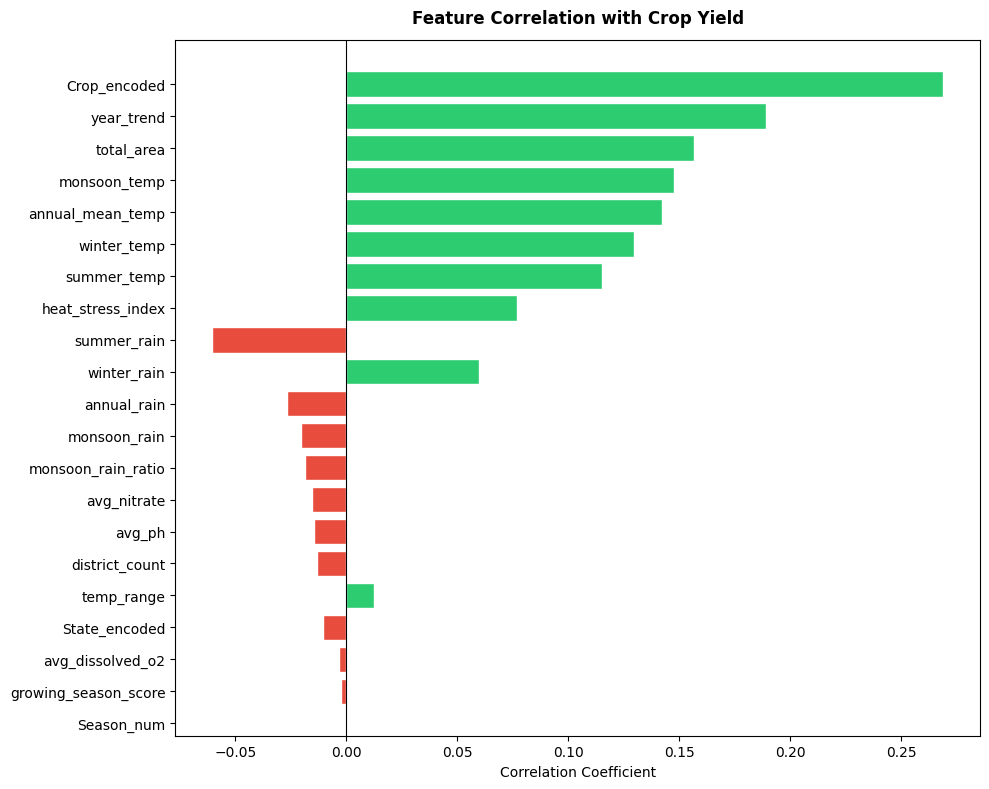

Top 10 features by correlation with yield:
Crop_encoded         0.268897
year_trend           0.188918
total_area           0.156704
monsoon_temp         0.147742
annual_mean_temp     0.142107
winter_temp          0.129418
summer_temp          0.115324
heat_stress_index    0.077002
summer_rain         -0.060541
winter_rain          0.059685
Name: avg_yield, dtype: float64


In [44]:
# ── Feature correlation chart ──
corr_with_target = (
    ml_df[ML_FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c'
          for v in corr_with_target.values]
plt.barh(corr_with_target.index[::-1],
         corr_with_target.values[::-1],
         color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Crop Yield',
          fontweight='bold', pad=12)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features by correlation with yield:")
print(corr_with_target.head(10))

***# Save all outputs:***

In [45]:
# ── Save all outputs ──
import pickle, json

ml_df.to_csv('master_ml_dataset.csv', index=False)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump({'crop': le_crop, 'state': le_state}, f)

with open('ml_features.json', 'w') as f:
    json.dump({'features': ML_FEATURES, 'target': TARGET}, f)

print("✓ Files saved:")
print("  master_ml_dataset.csv")
print("  label_encoders.pkl")
print("  ml_features.json")

✓ Files saved:
  master_ml_dataset.csv
  label_encoders.pkl
  ml_features.json


In [46]:
# ── Cell 13: Final summary ──
print("=" * 55)
print("WEEK 7 — MASTER DATASET SUMMARY")
print("=" * 55)
print(f"\nTotal samples:     {len(ml_df):,}")
print(f"Total features:    {len(ML_FEATURES)}")
print(f"States covered:    {ml_df['State'].nunique()}")
print(f"Crops covered:     {ml_df['Crop'].nunique()}")
print(f"Year range:        {ml_df['Crop_Year'].min()} – {ml_df['Crop_Year'].max()}")
print(f"\nTarget (avg_yield):")
print(f"  Min:    {ml_df['avg_yield'].min():.3f} kg/ha")
print(f"  Max:    {ml_df['avg_yield'].max():.3f} kg/ha")
print(f"  Mean:   {ml_df['avg_yield'].mean():.3f} kg/ha")
print(f"  Median: {ml_df['avg_yield'].median():.3f} kg/ha")
print(f"\nMissing values:    {ml_df.isnull().sum().sum()}")
print(f"\nTop 5 features by correlation:")
for feat, val in corr_with_target.head(5).items():
    print(f"  {feat:30s}: {val:+.3f}")
print("\n✓ Dataset ready for XGBoost in Week 8!")

WEEK 7 — MASTER DATASET SUMMARY

Total samples:     6,858
Total features:    21
States covered:    36
Crops covered:     10
Year range:        1997 – 2020

Target (avg_yield):
  Min:    0.006 kg/ha
  Max:    5.300 kg/ha
  Mean:   1.589 kg/ha
  Median: 1.372 kg/ha

Missing values:    0

Top 5 features by correlation:
  Crop_encoded                  : +0.269
  year_trend                    : +0.189
  total_area                    : +0.157
  monsoon_temp                  : +0.148
  annual_mean_temp              : +0.142

✓ Dataset ready for XGBoost in Week 8!
